In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X,y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

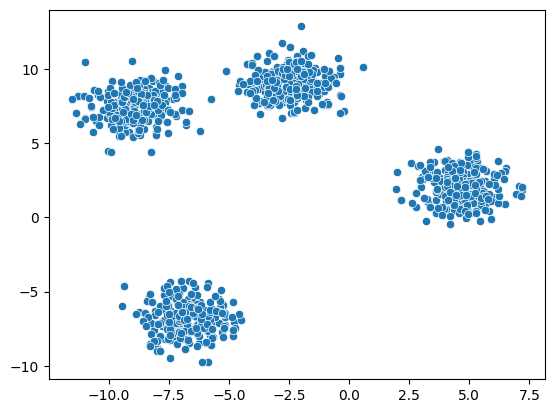

In [4]:
## visualize
sns.scatterplot(x=X[:,0], y=X[:,1])

In [5]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [7]:
K=4
kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

In [8]:
labels = kmeans.fit_predict(X)
# label = cluster number

<Axes: >

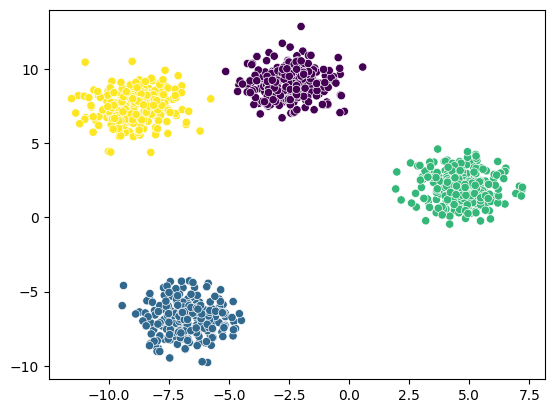

In [9]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

### Elbow Method

In [10]:
wcss = []
for k in range(1,21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

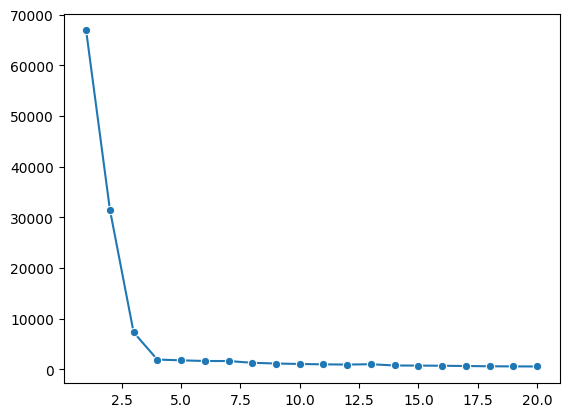

In [12]:
sns.lineplot(x=range(1,21), y=wcss, marker='o')

In [13]:
!pip install kneed


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from kneed import KneeLocator

In [15]:
knee = KneeLocator(range(1,21), wcss, curve='convex', direction='decreasing')

In [16]:
print('optimal K =', knee.elbow)

optimal K = 4


### Silhouette Score

In [17]:
from sklearn.metrics import silhouette_score

In [18]:
ss = []

for k in range(2,21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)

    ss.append(score)

<Axes: >

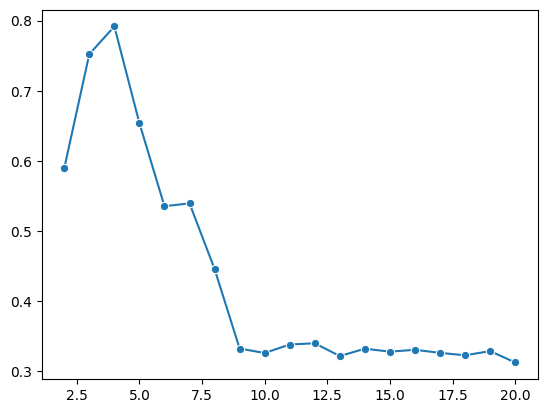

In [19]:
# plot - K & ss

sns.lineplot(x=range(2, 21), y=ss, marker='o')